# 05 — Model Training

Trains **GBR** (HistGradientBoostingRegressor) and **CatBoost** on all combinations of:
- 4 turbidity datasets (base, log1p, trimmed 1–99, Yeo-Johnson)
- 5 patch sizes (16 → 256 px)

**Total runs:** 4 × 5 × 2 = **40 training experiments**

Hyperparameter optimisation: **Optuna** (TPE, 30 trials) with **GroupKFold** CV (k=5) inside each objective.

**Outputs** in `results/`:
- `model_metrics.csv` — all 40 combinations with train/OOF/CV/test metrics
- `test_predictions.csv` — per-sample test set predictions
- `oof_predictions.csv` — out-of-fold train predictions
- `best_model_info.json` — best combination pointer
- `models/` — fitted model pickles

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42

## 1. Configuration

In [2]:
BASE_DIR = Path('..')
FE_DIR   = BASE_DIR / 'data' / 'processed' / 'feature_engineering'
PROC_DIR = BASE_DIR / 'data' / 'processed'
RES_DIR  = BASE_DIR / 'results'
MOD_DIR  = RES_DIR / 'models'
for d in [RES_DIR, MOD_DIR]:
    d.mkdir(exist_ok=True)

# 4 turbidity datasets — different target transformations
DATASET_CONFIG = {
    'base':       {'file': 'dataset_base.csv',         'clip_at_zero': True},
    'log1p':      {'file': 'dataset_log1p.csv',        'clip_at_zero': True},
    'trimmed':    {'file': 'dataset_trimmed_1_99.csv', 'clip_at_zero': True},
    'yeojohnson': {'file': 'dataset_yeojohnson.csv',   'clip_at_zero': False},
}

# 5 circular patch sizes
PATCH_CONFIG = [
    {'px': 16,  'diameter_m': 48},
    {'px': 32,  'diameter_m': 96},
    {'px': 64,  'diameter_m': 192},
    {'px': 128, 'diameter_m': 384},
    {'px': 256, 'diameter_m': 768},
]

META_COLS        = ['ctd', 'date', 'turbidity']
TEST_FRAC        = 0.20
N_CV_SPLITS      = 5
EARLY_STOP       = 50
N_MAX_ITERS      = 800
N_OPTUNA_TRIALS  = 30

print(f'Datasets   : {list(DATASET_CONFIG.keys())}')
print(f'Patch sizes: {[c["px"] for c in PATCH_CONFIG]} px')
print(f'Models     : GBR, CatBoost')

Datasets   : ['base', 'log1p', 'trimmed', 'yeojohnson']
Patch sizes: [16, 32, 64, 128, 256] px
Models     : GBR, CatBoost


## 2. Data loading and utility functions

In [3]:
def load_training_data(patch_px: int, ds_name: str):
    """
    Merge feature file (from 04_feature_engineering) with a turbidity dataset.

    Returns (df, feat_cols) where df has cols ctd + date + turbidity + features.
    """
    feat_path = FE_DIR / f'fe_{patch_px}px.parquet'
    if not feat_path.exists():
        raise FileNotFoundError(f'{feat_path} not found — run 04_feature_engineering first.')

    df_feat = pd.read_parquet(feat_path)
    df_feat['date'] = pd.to_datetime(df_feat['date']).dt.date
    df_feat['ctd']  = df_feat['ctd'].astype(str)

    cfg     = DATASET_CONFIG[ds_name]
    df_turb = pd.read_csv(PROC_DIR / cfg['file'])
    df_turb['date'] = pd.to_datetime(df_turb['date']).dt.date
    df_turb['ctd']  = df_turb['ctd'].astype(str)

    df = df_feat.merge(df_turb[['ctd', 'date', 'turbidity']], on=['ctd', 'date'], how='inner')
    df = df.dropna(subset=['turbidity']).reset_index(drop=True)

    feat_cols = [c for c in df.columns if c not in META_COLS]
    return df, feat_cols


def temporal_split(df):
    """80/20 chronological split without temporal leakage."""
    dates  = sorted(df['date'].unique())
    n_test = max(1, int(len(dates) * TEST_FRAC))
    tr_d   = dates[:-n_test]
    te_d   = dates[-n_test:]
    return (df[df['date'].isin(tr_d)].reset_index(drop=True),
            df[df['date'].isin(te_d)].reset_index(drop=True))


def compute_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    return dict(
        mae       = round(mean_absolute_error(y_true, y_pred), 4),
        rmse      = round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        r2        = round(r2_score(y_true, y_pred), 4),
        pearson_r = round(float(pearsonr(y_true, y_pred)[0]), 4),
        bias      = round(float(np.mean(y_pred - y_true)), 4),
    )


print('Utility functions loaded.')

Utility functions loaded.


## 3. Optuna objectives

Bayesian (TPE) search with GroupKFold inside the objective — no temporal leakage during tuning.

In [4]:
def _gbr_objective(trial, X_tr, y_tr, groups):
    params = dict(
        learning_rate     = trial.suggest_float('learning_rate',     0.01, 0.30, log=True),
        max_leaf_nodes    = trial.suggest_int(  'max_leaf_nodes',    15, 127),
        min_samples_leaf  = trial.suggest_int(  'min_samples_leaf',  1, 40),
        l2_regularization = trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        max_features      = trial.suggest_float('max_features',      0.5, 1.0),
        loss              = trial.suggest_categorical('loss', ['squared_error', 'absolute_error']),
    )
    kf     = GroupKFold(n_splits=N_CV_SPLITS)
    scores = []
    for tr_idx, val_idx in kf.split(X_tr, y_tr, groups):
        m = HistGradientBoostingRegressor(
            max_iter=N_MAX_ITERS,
            n_iter_no_change=EARLY_STOP,
            validation_fraction=0.12,
            random_state=RANDOM_STATE,
            **params
        )
        m.fit(X_tr[tr_idx], y_tr[tr_idx])
        scores.append(mean_absolute_error(y_tr[val_idx], m.predict(X_tr[val_idx])))
    return float(np.mean(scores))


def _cat_objective(trial, X_tr, y_tr, groups):
    params = dict(
        depth               = trial.suggest_int(  'depth',               4, 10),
        learning_rate       = trial.suggest_float('learning_rate',       0.01, 0.30, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg',         1.0, 20.0),
        min_data_in_leaf    = trial.suggest_int(  'min_data_in_leaf',    1, 20),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 2.0),
    )
    kf     = GroupKFold(n_splits=N_CV_SPLITS)
    scores = []
    for tr_idx, val_idx in kf.split(X_tr, y_tr, groups):
        m = CatBoostRegressor(
            iterations=N_MAX_ITERS,
            loss_function='MAE',
            eval_metric='MAE',
            bootstrap_type='Bayesian',
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            **params
        )
        m.fit(X_tr[tr_idx], y_tr[tr_idx],
              eval_set=(X_tr[val_idx], y_tr[val_idx]),
              early_stopping_rounds=EARLY_STOP,
              verbose=False)
        scores.append(mean_absolute_error(y_tr[val_idx], m.predict(X_tr[val_idx])))
    return float(np.mean(scores))


def run_optuna(model_type, X_tr, y_tr, groups, n_trials=N_OPTUNA_TRIALS):
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    if model_type == 'GBR':
        obj = lambda t: _gbr_objective(t, X_tr, y_tr, groups)
    else:
        obj = lambda t: _cat_objective(t, X_tr, y_tr, groups)
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    print(f'    Optuna({n_trials} trials): CV_MAE={study.best_value:.4f}')
    return dict(study.best_params)


print('Optuna objectives loaded.')

Optuna objectives loaded.


## 4. CV with early stopping and final training

In [5]:
def cv_early_stopping(model_type, X_tr, y_tr, groups, best_params):
    """
    GroupKFold CV with early stopping.
    Returns (oof_preds, fold_metrics, best_iters_per_fold).
    """
    kf      = GroupKFold(n_splits=N_CV_SPLITS)
    oof     = np.full(len(y_tr), np.nan)
    fold_met = []
    best_its = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tr, y_tr, groups)):
        Xtr, Xval = X_tr[tr_idx], X_tr[val_idx]
        ytr, yval = y_tr[tr_idx], y_tr[val_idx]

        if model_type == 'GBR':
            # Remove 'loss' if present (only valid GBR-specific keys)
            p = {k: v for k, v in best_params.items()}
            m = HistGradientBoostingRegressor(
                max_iter=N_MAX_ITERS,
                n_iter_no_change=EARLY_STOP,
                validation_fraction=0.12,
                random_state=RANDOM_STATE,
                **p
            )
            m.fit(Xtr, ytr)
            best_its.append(m.n_iter_)
            pred = m.predict(Xval)

        else:  # CatBoost
            p = {k: v for k, v in best_params.items() if k != 'loss'}
            m = CatBoostRegressor(
                iterations=N_MAX_ITERS,
                loss_function='MAE',
                eval_metric='MAE',
                bootstrap_type='Bayesian',
                random_seed=RANDOM_STATE,
                thread_count=-1,
                verbose=False,
                **p
            )
            m.fit(Xtr, ytr,
                  eval_set=(Xval, yval),
                  early_stopping_rounds=EARLY_STOP,
                  verbose=False)
            best_its.append(m.get_best_iteration())
            pred = m.predict(Xval)

        oof[val_idx] = pred
        fold_met.append(compute_metrics(yval, pred))

    return oof, fold_met, best_its


def train_final(model_type, X_tr, y_tr, best_its, best_params):
    """Train final model on full training set. n_iters = round(mean CV best_iters) + 1."""
    n_iters = max(int(round(np.mean(best_its))) + 1, 10)

    if model_type == 'GBR':
        p = {k: v for k, v in best_params.items()}
        m = HistGradientBoostingRegressor(
            max_iter=n_iters,
            random_state=RANDOM_STATE,
            **p
        )
        m.fit(X_tr, y_tr)
    else:
        p = {k: v for k, v in best_params.items() if k != 'loss'}
        m = CatBoostRegressor(
            iterations=n_iters,
            loss_function='MAE',
            eval_metric='MAE',
            bootstrap_type='Bayesian',
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            **p
        )
        m.fit(X_tr, y_tr, verbose=False)

    return m, n_iters


print('CV and training functions loaded.')

CV and training functions loaded.


## 5. Training loop: 4 datasets × 5 patches × 2 models

In [6]:
models_to_train = ['GBR', 'CatBoost']

all_results  = []
oof_records  = []
test_records = []

total_runs = len(DATASET_CONFIG) * len(PATCH_CONFIG) * len(models_to_train)
run_idx    = 0

print(f'Starting {total_runs} training runs...\n')

for ds_name, ds_cfg in DATASET_CONFIG.items():
    for pc in PATCH_CONFIG:
        px = pc['px']

        # Load features + turbidity labels
        try:
            df, feat_cols = load_training_data(px, ds_name)
        except FileNotFoundError as e:
            print(f'  SKIP [{ds_name}/{px}px] {e}')
            continue

        tr_df, te_df = temporal_split(df)

        X_tr = tr_df[feat_cols].values.astype(np.float64)
        X_te = te_df[feat_cols].values.astype(np.float64)
        y_tr = tr_df['turbidity'].values
        y_te = te_df['turbidity'].values

        # GroupKFold groups by date (no temporal leakage across folds)
        groups = pd.Categorical(tr_df['date']).codes

        for mtype in models_to_train:
            run_idx += 1
            print(f'[{run_idx}/{total_runs}] dataset={ds_name:10s}  patch={px:3d}px  model={mtype}')

            print(f'  Searching hyperparameters ({N_OPTUNA_TRIALS} trials)...', flush=True)
            best_params = run_optuna(mtype, X_tr, y_tr, groups)

            print(f'  CV (k={N_CV_SPLITS})...', flush=True)
            oof, fold_met, best_its = cv_early_stopping(mtype, X_tr, y_tr, groups, best_params)

            cv_mae     = float(np.mean([m['mae']  for m in fold_met]))
            cv_mae_std = float(np.std( [m['mae']  for m in fold_met]))
            cv_rmse    = float(np.mean([m['rmse'] for m in fold_met]))
            cv_r2      = float(np.mean([m['r2']   for m in fold_met]))

            final_model, n_iters = train_final(mtype, X_tr, y_tr, best_its, best_params)

            clip = ds_cfg['clip_at_zero']

            tr_pred  = final_model.predict(X_tr)
            te_pred  = final_model.predict(X_te)
            if clip:
                tr_pred = np.maximum(tr_pred, 0.0)
                te_pred = np.maximum(te_pred, 0.0)
                oof     = np.where(np.isnan(oof), np.nan, np.maximum(oof, 0.0))

            tr_met  = compute_metrics(y_tr, tr_pred)
            te_met  = compute_metrics(y_te, te_pred)
            oof_met = compute_metrics(y_tr, oof)

            print(f'  n_iters={n_iters:4d} | '
                  f'Train MAE={tr_met["mae"]:.3f} R²={tr_met["r2"]:.3f} | '
                  f'OOF MAE={oof_met["mae"]:.3f} | '
                  f'CV {cv_mae:.3f}±{cv_mae_std:.3f} | '
                  f'Test MAE={te_met["mae"]:.3f} R²={te_met["r2"]:.3f}')

            model_key = f'{ds_name}__{px}px__{mtype}'
            pickle.dump(final_model, open(MOD_DIR / f'{model_key}.pkl', 'wb'))
            pickle.dump(feat_cols,   open(MOD_DIR / f'{model_key}__feat_cols.pkl', 'wb'))

            all_results.append({
                'dataset': ds_name, 'patch_px': px, 'diameter_m': pc['diameter_m'],
                'model': mtype,
                'n_train': len(tr_df), 'n_test': len(te_df),
                'n_features': len(feat_cols), 'n_iters': n_iters,
                **{f'train_{k}': v for k, v in tr_met.items()},
                **{f'test_{k}':  v for k, v in te_met.items()},
                **{f'oof_{k}':   v for k, v in oof_met.items()},
                'cv_mae':          round(cv_mae, 4),
                'cv_mae_std':      round(cv_mae_std, 4),
                'cv_rmse':         round(cv_rmse, 4),
                'cv_r2':           round(cv_r2, 4),
                'best_iter_mean':  round(float(np.mean(best_its)), 1),
                'best_iter_std':   round(float(np.std(best_its)), 1),
                'best_params':     json.dumps(best_params),
            })

            for row_df, pred_val in zip(te_df.itertuples(index=False), te_pred):
                test_records.append({
                    'ctd': row_df.ctd, 'date': str(row_df.date),
                    'turbidity': row_df.turbidity, 'pred': round(float(pred_val), 6),
                    'dataset': ds_name, 'patch_px': px, 'model': mtype,
                })

            for row_df, oof_val in zip(tr_df.itertuples(index=False), oof):
                oof_records.append({
                    'ctd': row_df.ctd, 'date': str(row_df.date),
                    'turbidity': row_df.turbidity, 'pred': round(float(oof_val), 6),
                    'dataset': ds_name, 'patch_px': px, 'model': mtype,
                })

print(f'\nTraining complete — {run_idx} runs finished.')

Starting 40 training runs...

[1/40] dataset=base        patch= 16px  model=GBR
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.8251
  CV (k=5)...
  n_iters= 801 | Train MAE=0.482 R²=0.209 | OOF MAE=0.810 | CV 0.825±0.428 | Test MAE=0.555 R²=-0.314
[2/40] dataset=base        patch= 16px  model=CatBoost
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.7681
  CV (k=5)...
  n_iters=  21 | Train MAE=0.386 R²=0.465 | OOF MAE=0.754 | CV 0.768±0.418 | Test MAE=0.634 R²=-1.092
[3/40] dataset=base        patch= 32px  model=GBR
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.8222
  CV (k=5)...
  n_iters= 801 | Train MAE=0.519 R²=0.165 | OOF MAE=0.806 | CV 0.822±0.451 | Test MAE=0.528 R²=-0.235
[4/40] dataset=base        patch= 32px  model=CatBoost
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.7708
  CV (k=5)...
  n_iters=  10 | Train MAE=0.576 R²=0.135 | OOF MAE=0.755 | CV 0.771±0.448 | T

## 6. Save metrics and predictions to CSV

In [7]:
metrics_df = pd.DataFrame(all_results)
test_df    = pd.DataFrame(test_records)
oof_df     = pd.DataFrame(oof_records)

metrics_df.to_csv(RES_DIR / 'model_metrics.csv',      index=False)
test_df.to_csv(   RES_DIR / 'test_predictions.csv',   index=False)
oof_df.to_csv(    RES_DIR / 'oof_predictions.csv',    index=False)

# Best model (lowest test MAE)
best_row = metrics_df.loc[metrics_df['test_mae'].idxmin()]
best_cfg = {
    'best_dataset':   best_row['dataset'],
    'best_patch_px':  int(best_row['patch_px']),
    'best_model':     best_row['model'],
    'diameter_m':     int(best_row['diameter_m']),
    'test_mae':       float(best_row['test_mae']),
    'test_r2':        float(best_row['test_r2']),
    'model_file':     f'{best_row["dataset"]}__{best_row["patch_px"]}px__{best_row["model"]}.pkl',
    'feat_cols_file': f'{best_row["dataset"]}__{best_row["patch_px"]}px__{best_row["model"]}__feat_cols.pkl',
}
with open(RES_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_cfg, f, indent=2)
with open(RES_DIR / 'dataset_config.json', 'w') as f:
    json.dump(DATASET_CONFIG, f, indent=2)

print(f'Saved model_metrics.csv     ({len(metrics_df)} rows)')
print(f'Saved test_predictions.csv  ({len(test_df)} rows)')
print(f'Saved oof_predictions.csv   ({len(oof_df)} rows)')
print(f'\nBest combination:')
print(f'  dataset={best_cfg["best_dataset"]}  patch={best_cfg["best_patch_px"]}px  '
      f'model={best_cfg["best_model"]}')
print(f'  Test MAE={best_cfg["test_mae"]:.4f}  R²={best_cfg["test_r2"]:.4f}')

Saved model_metrics.csv     (40 rows)
Saved test_predictions.csv  (2704 rows)
Saved oof_predictions.csv   (10356 rows)

Best combination:
  dataset=log1p  patch=256px  model=CatBoost
  Test MAE=0.2410  R²=-0.3617


## 7. Results table

In [8]:
cols_show = ['dataset', 'patch_px', 'model',
             'train_mae', 'train_r2',
             'oof_mae',
             'cv_mae', 'cv_mae_std',
             'test_mae', 'test_rmse', 'test_r2',
             'n_iters']

display(
    metrics_df[cols_show]
    .sort_values('test_mae')
    .reset_index(drop=True)
    .rename(columns={
        'patch_px':    'patch',
        'train_mae':   'Train MAE', 'train_r2':  'Train R²',
        'oof_mae':     'OOF MAE',
        'cv_mae':      'CV MAE',    'cv_mae_std': 'CV ±',
        'test_mae':    'Test MAE',  'test_rmse':  'Test RMSE', 'test_r2': 'Test R²',
    })
)

,dataset,patch,model,Train MAE,Train R²,OOF MAE,CV MAE,CV ±,Test MAE,Test RMSE,Test R²,n_iters
0,log1p,256,CatBoost,0.2339,0.2388,0.2974,0.2985,0.1102,0.2410,0.2867,-0.3617,11
1,log1p,32,GBR,0.1854,0.3866,0.3319,0.3357,0.1126,0.2563,0.3024,-0.4850,801
2,log1p,128,CatBoost,0.1982,0.4614,0.3022,0.3054,0.1058,0.2614,0.3029,-0.5853,35
3,log1p,64,GBR,0.1896,0.3754,0.3340,0.3380,0.1148,0.2632,0.3058,-0.5189,801
4,log1p,16,GBR,0.1731,0.4440,0.3305,0.3341,0.1054,0.2646,0.3097,-0.5585,801
5,log1p,64,CatBoost,0.2172,0.3441,0.3061,0.3098,0.1151,0.2696,0.3061,-0.5215,36
6,log1p,32,CatBoost,0.1853,0.4959,0.3050,0.3086,0.1138,0.2700,0.3172,-0.6347,31
7,log1p,256,GBR,0.2122,0.2632,0.3211,0.3221,0.1110,0.2710,0.3086,-0.5786,801
8,log1p,16,CatBoost,0.1494,0.6051,0.3031,0.3067,0.1115,0.2769,0.3244,-0.7094,111
9,log1p,128,GBR,0.1083,0.6964,0.3370,0.3403,0.1023,0.2792,0.3386,-0.9800,801


## 8. Visualisation

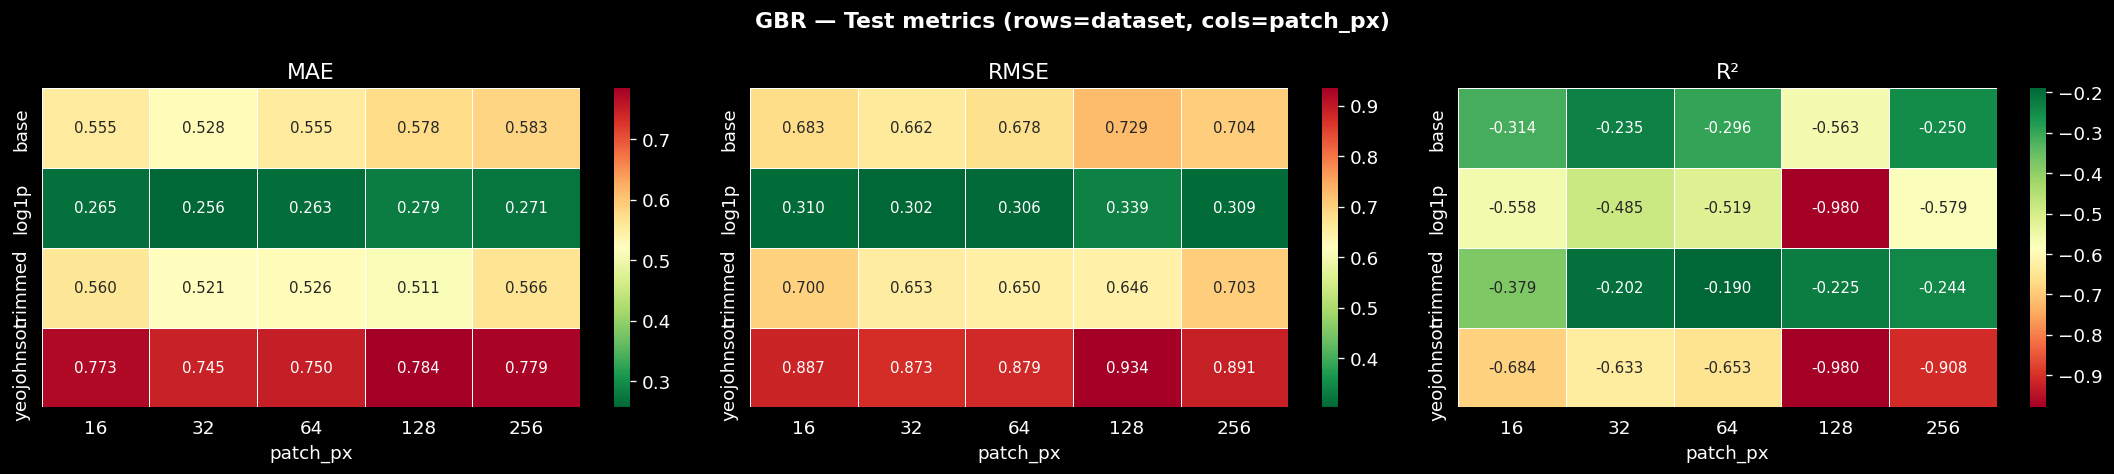

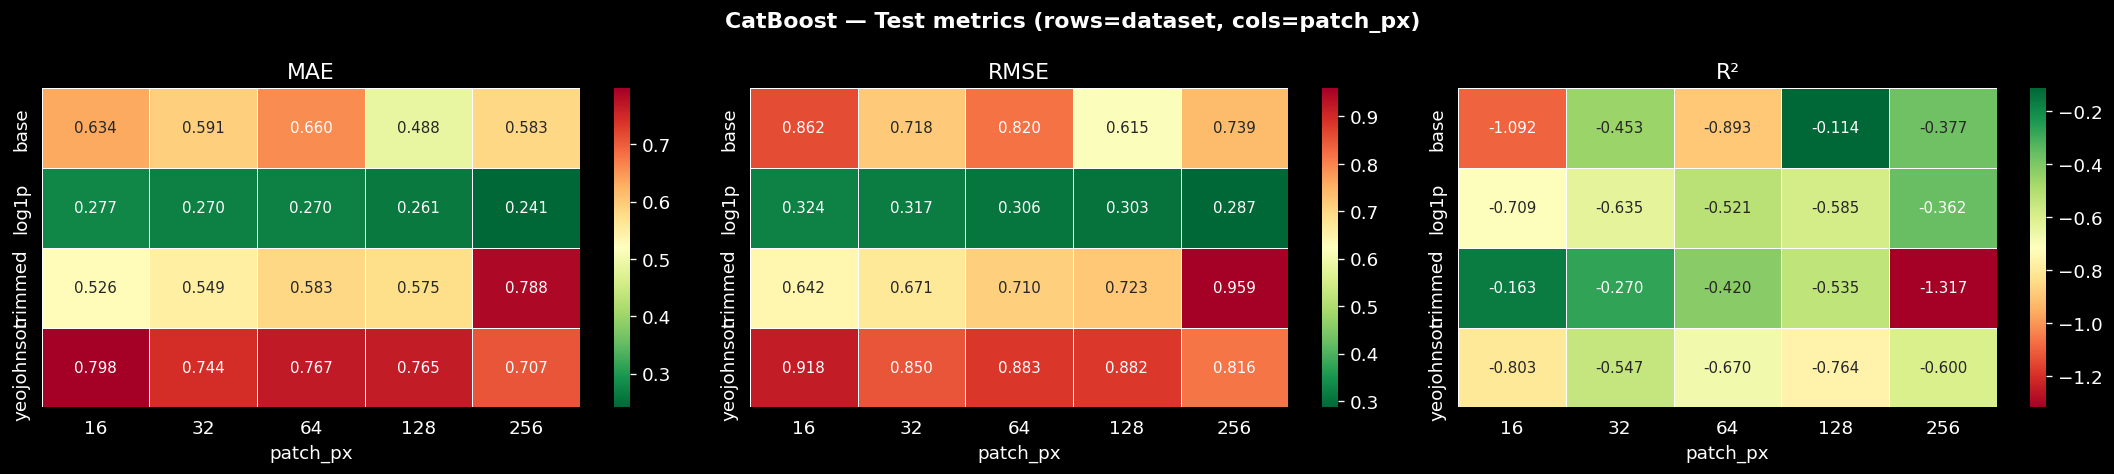

In [9]:
ds_order    = list(DATASET_CONFIG.keys())
px_order    = [c['px'] for c in PATCH_CONFIG]
model_order = ['GBR', 'CatBoost']

for mtype in model_order:
    sub = metrics_df[metrics_df['model'] == mtype]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'{mtype} — Test metrics (rows=dataset, cols=patch_px)', fontweight='bold')

    for ax, (metric, label, cmap) in zip(axes, [
        ('test_mae',  'MAE',  'RdYlGn_r'),
        ('test_rmse', 'RMSE', 'RdYlGn_r'),
        ('test_r2',   'R²',   'RdYlGn'),
    ]):
        pivot = sub.pivot(index='dataset', columns='patch_px', values=metric)
        pivot = pivot.reindex(
            index=[d for d in ds_order if d in pivot.index],
            columns=[p for p in px_order if p in pivot.columns]
        )
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                    ax=ax, linewidths=0.5, annot_kws={'size': 9})
        ax.set_title(label)
        ax.set_xlabel('patch_px')
        ax.set_ylabel('')

    plt.tight_layout()
    plt.savefig(RES_DIR / f'heatmap_{mtype}.png', bbox_inches='tight')
    plt.show()

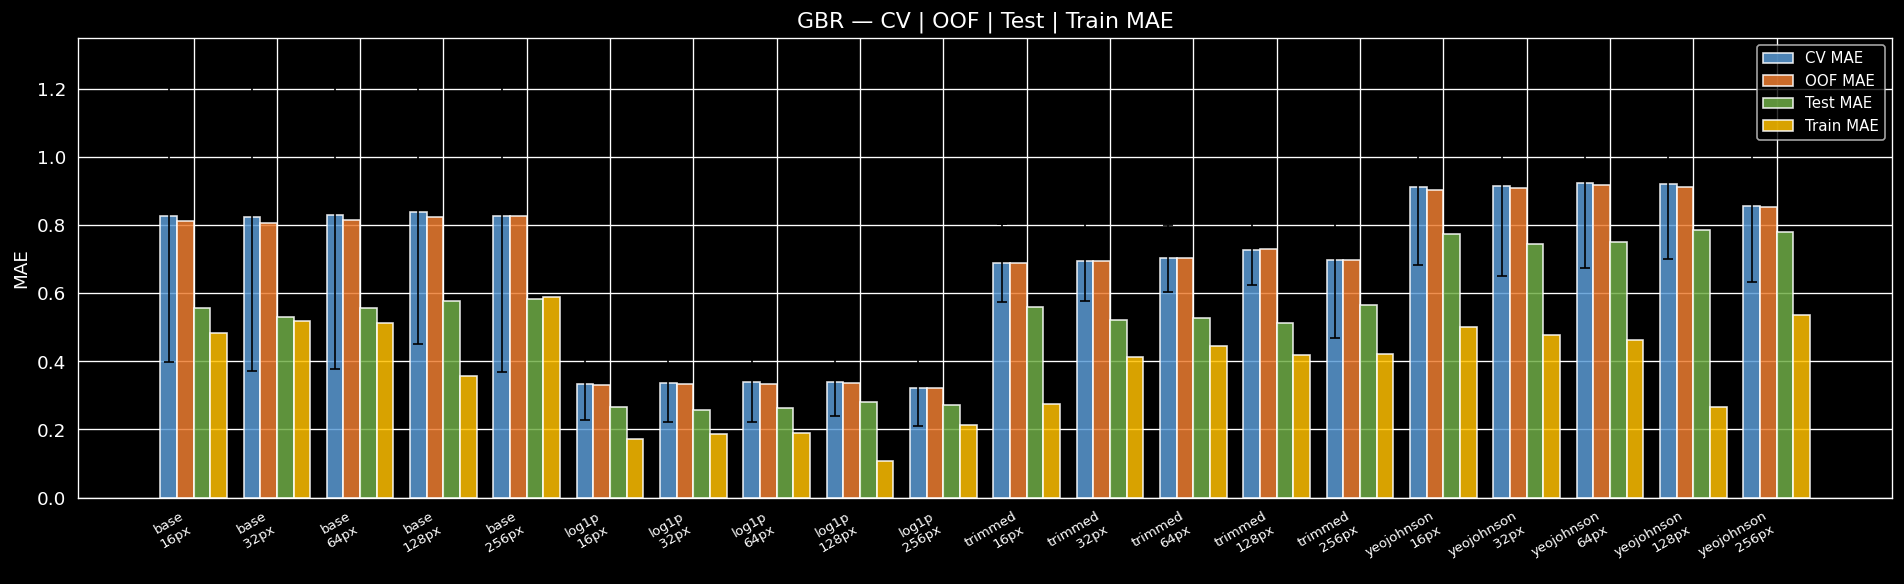

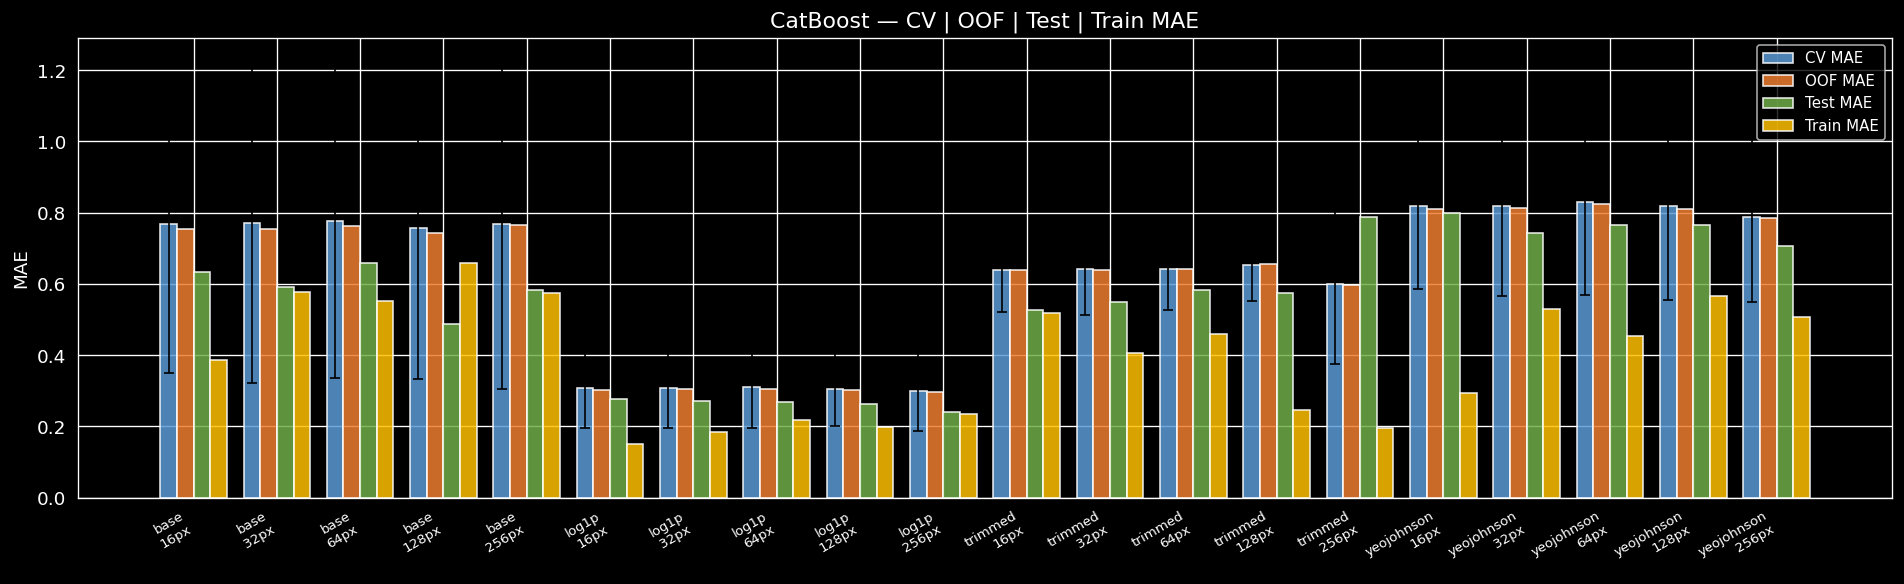

In [10]:
# Overfitting diagnosis: Train vs OOF vs CV vs Test MAE per dataset×model
for mtype in model_order:
    sub = metrics_df[metrics_df['model'] == mtype].copy()
    sub['label'] = sub['dataset'] + '\n' + sub['patch_px'].astype(str) + 'px'
    sub = sub.sort_values(['dataset', 'patch_px'])

    x = np.arange(len(sub))
    w = 0.20

    fig, ax = plt.subplots(figsize=(max(10, len(sub)*0.8), 5))
    ax.bar(x - 1.5*w, sub['cv_mae'],    width=w, label='CV MAE',    color='#5B9BD5', alpha=0.85)
    ax.bar(x - 0.5*w, sub['oof_mae'],   width=w, label='OOF MAE',   color='#ED7D31', alpha=0.85)
    ax.bar(x + 0.5*w, sub['test_mae'],  width=w, label='Test MAE',  color='#70AD47', alpha=0.85)
    ax.bar(x + 1.5*w, sub['train_mae'], width=w, label='Train MAE', color='#FFC000', alpha=0.85)
    ax.errorbar(x - 1.5*w, sub['cv_mae'], yerr=sub['cv_mae_std'],
                fmt='none', color='black', capsize=3, lw=1)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('MAE')
    ax.set_title(f'{mtype} — CV | OOF | Test | Train MAE')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(RES_DIR / f'overfitting_{mtype}.png', bbox_inches='tight')
    plt.show()

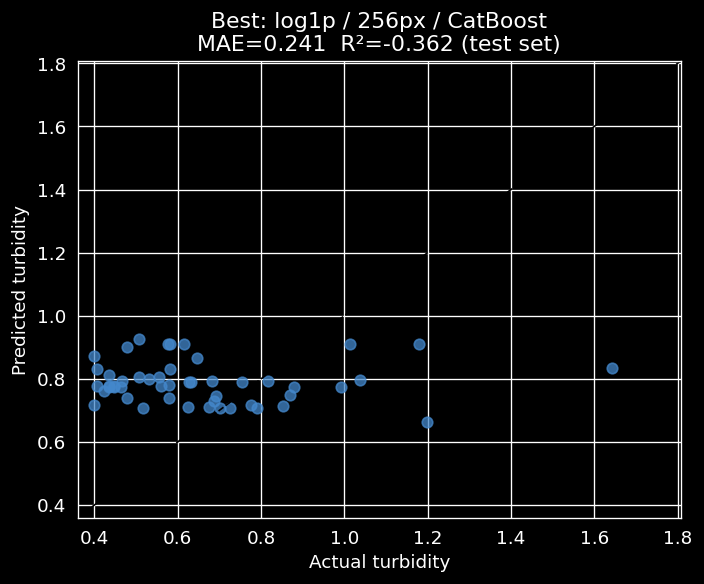

In [11]:
# Scatter predicted vs actual for best combination
best_info = json.load(open(RES_DIR / 'best_model_info.json'))

mask = ((test_df['dataset']  == best_info['best_dataset']) &
        (test_df['patch_px'] == best_info['best_patch_px']) &
        (test_df['model']    == best_info['best_model']))
sub_test = test_df[mask]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sub_test['turbidity'], sub_test['pred'], alpha=0.75, s=40, color='#4488cc')
lim = [min(sub_test['turbidity'].min(), sub_test['pred'].min()) * 0.9,
       max(sub_test['turbidity'].max(), sub_test['pred'].max()) * 1.1]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual turbidity')
ax.set_ylabel('Predicted turbidity')
ax.set_title(f'Best: {best_info["best_dataset"]} / {best_info["best_patch_px"]}px / '
             f'{best_info["best_model"]}\n'
             f'MAE={best_info["test_mae"]:.3f}  R²={best_info["test_r2"]:.3f} (test set)')
plt.tight_layout()
plt.savefig(RES_DIR / 'best_model_scatter.png', bbox_inches='tight')
plt.show()

## 9. Best configuration per dataset

In [12]:
best_per_ds = (
    metrics_df.sort_values('test_mae')
    .groupby('dataset', sort=False)
    .first()
    [['patch_px', 'model', 'train_mae', 'oof_mae', 'cv_mae', 'test_mae', 'test_r2', 'n_iters']]
    .rename(columns={
        'patch_px': 'best_patch', 'model': 'best_model',
        'train_mae': 'Train MAE', 'oof_mae': 'OOF MAE',
        'cv_mae': 'CV MAE', 'test_mae': 'Test MAE', 'test_r2': 'Test R²',
    })
)

print('Best combination per dataset (by test MAE):')
display(best_per_ds)

print(f'\nGlobal best: {best_info["best_dataset"]} / {best_info["best_patch_px"]}px / '
      f'{best_info["best_model"]}  →  Test MAE={best_info["test_mae"]:.4f}')

Best combination per dataset (by test MAE):


,best_patch,best_model,Train MAE,OOF MAE,CV MAE,Test MAE,Test R²,n_iters
dataset,,,,,,,,
log1p,256,CatBoost,0.2339,0.2974,0.2985,0.2410,-0.3617,11
base,128,CatBoost,0.6593,0.7439,0.7578,0.4879,-0.1135,51
trimmed,128,GBR,0.4182,0.7303,0.7276,0.5113,-0.2252,801
yeojohnson,256,CatBoost,0.5057,0.7848,0.7881,0.7067,-0.5998,10



Global best: log1p / 256px / CatBoost  →  Test MAE=0.2410
